<a href="https://colab.research.google.com/github/Sharris9/Test_1_IGP.pyclass/blob/main/Heatmaps_MPNNdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


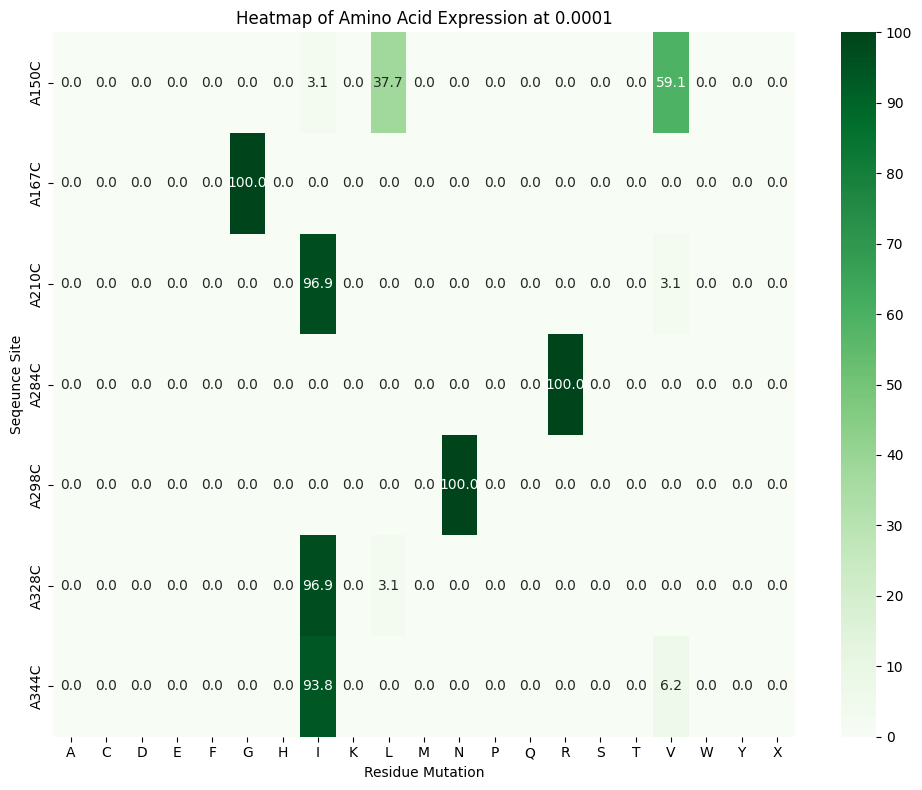

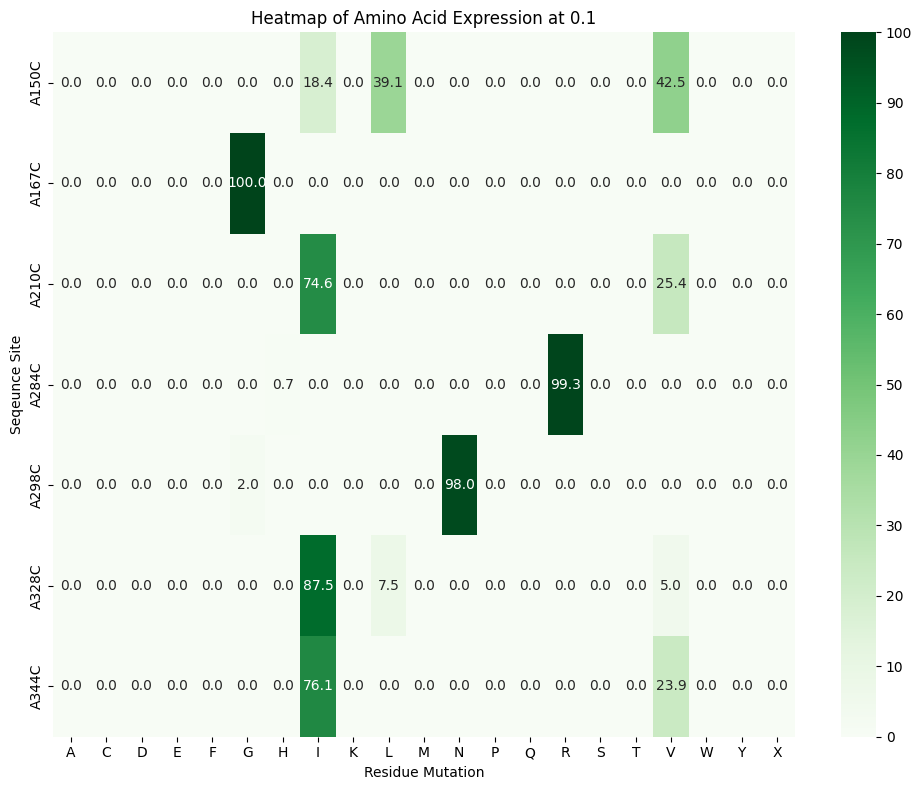

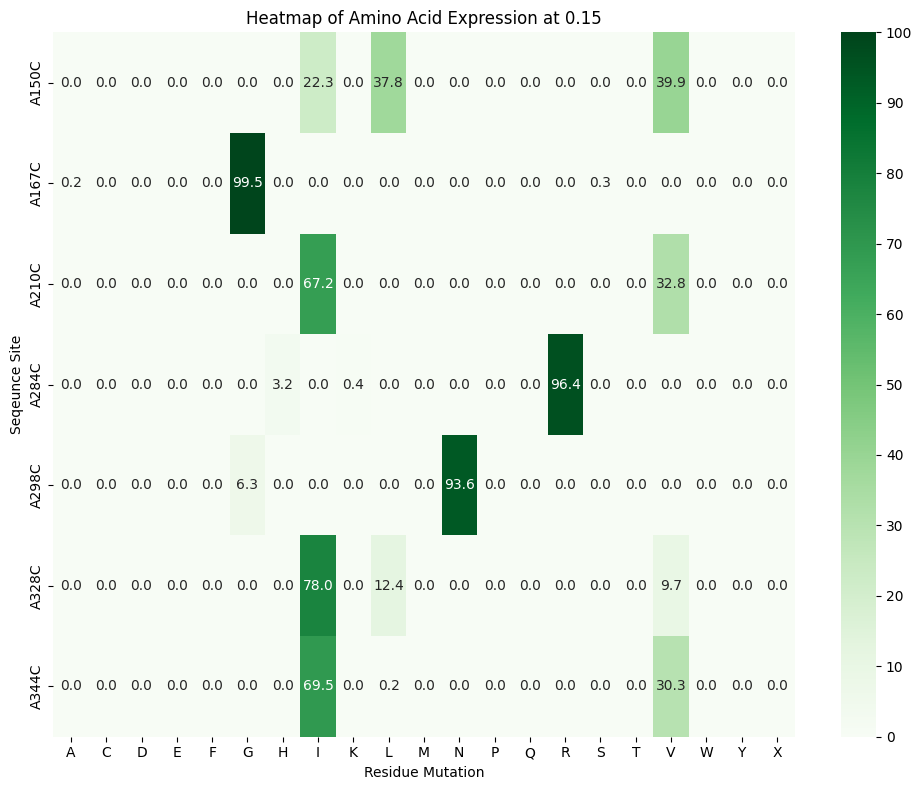

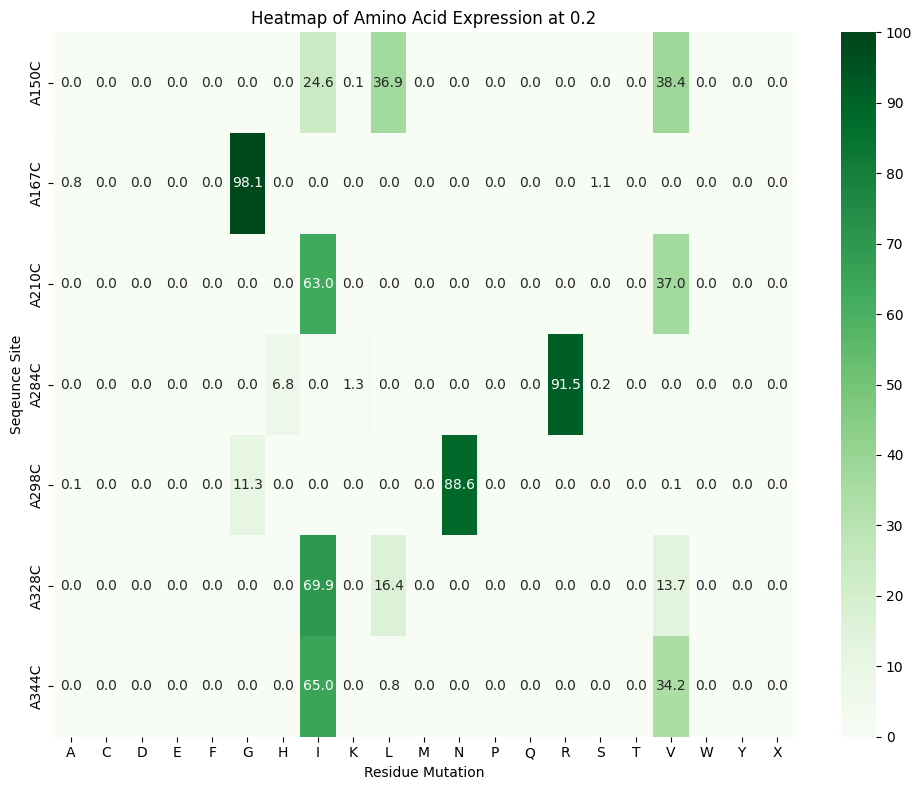

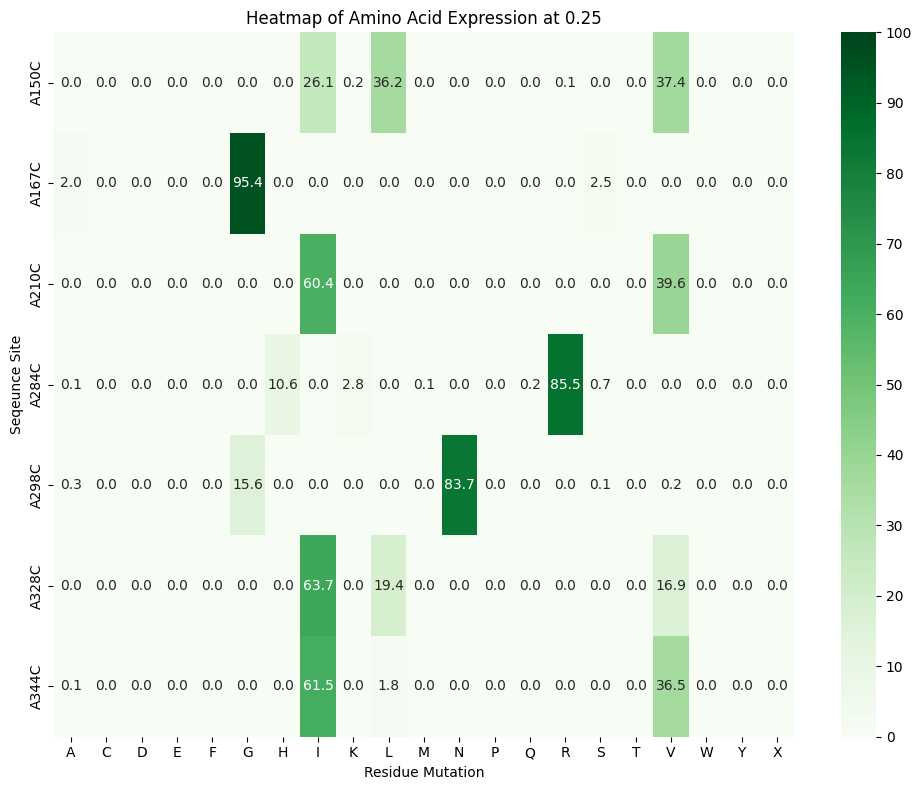

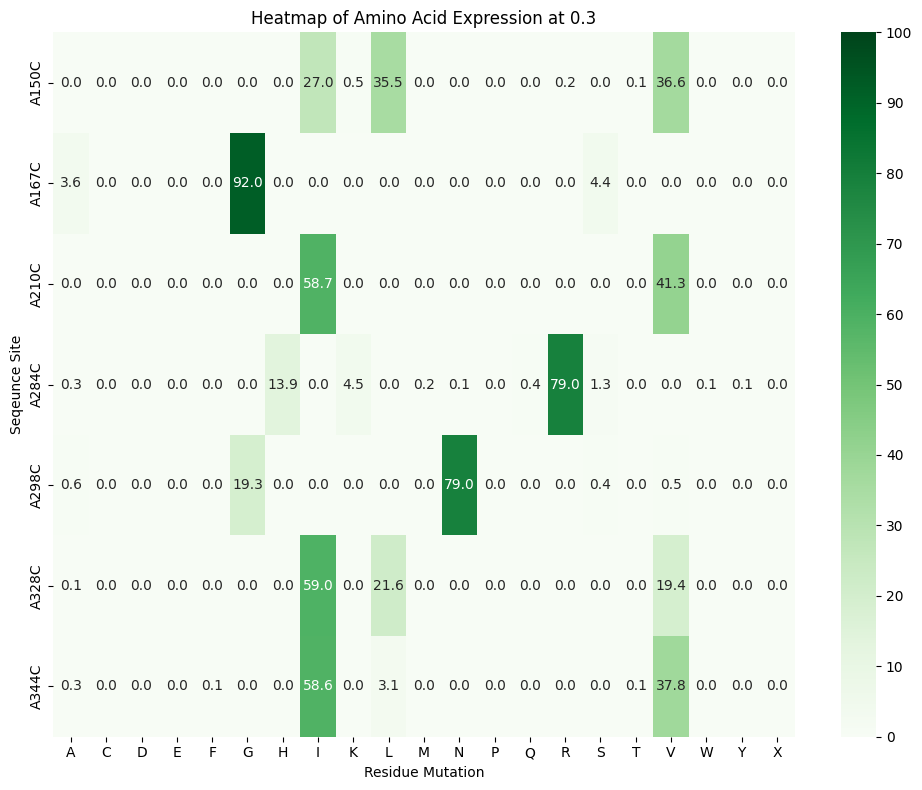

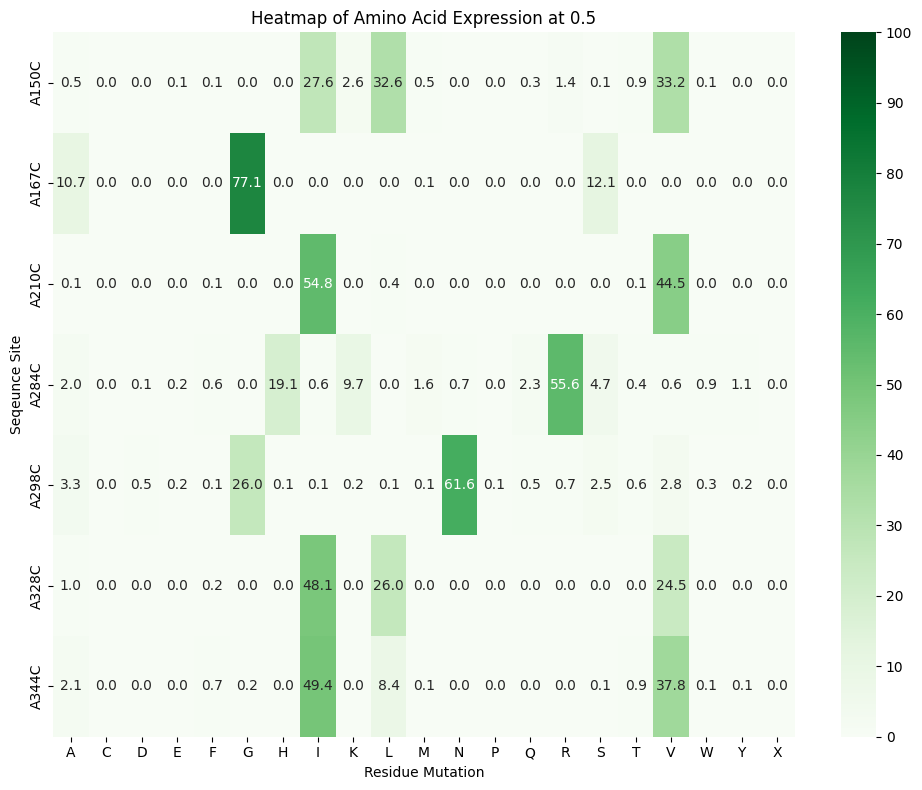

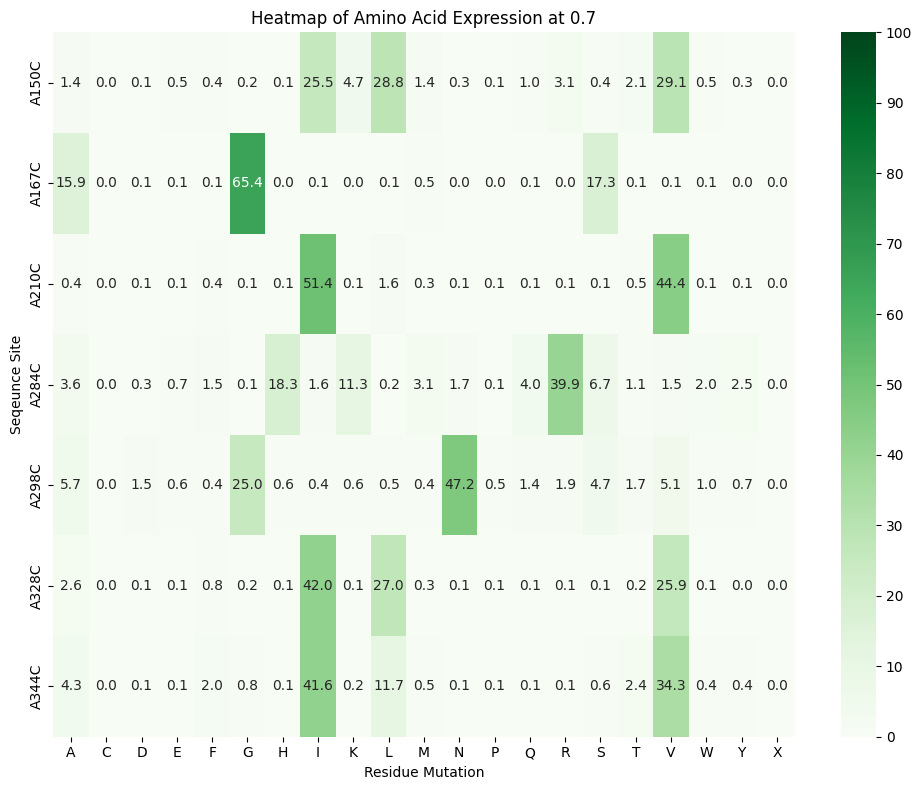

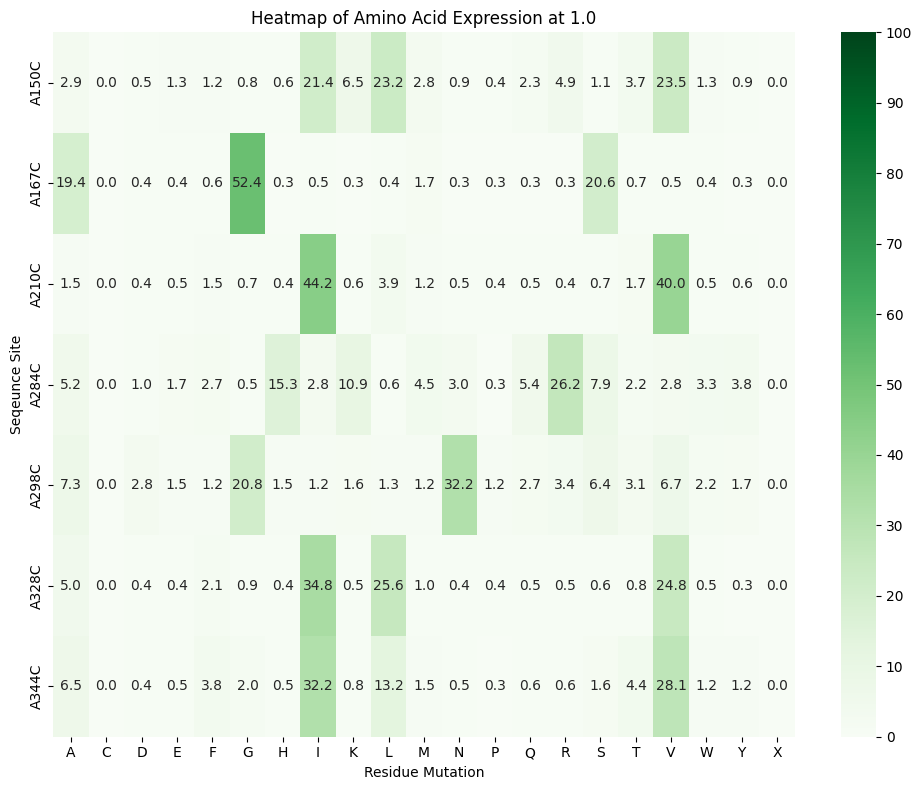

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Now you can access files in your Drive like regular files:
excel_file = '/content/MPNN_Temperature Data_mG6PC1.xlsx'  # Replace with the actual path

def create_heatmaps_from_excel(excel_file):
    """
    Generates heatmaps from an Excel file with a fixed legend range.

    Args:
        excel_file (str): Path to the Excel file.
    """

    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)

        for sheet_name, df in all_sheets.items():
            df = df.set_index(df.columns[0])

            try:
                df = df.apply(pd.to_numeric, errors='coerce')
            except Exception as e:
                print(f"Error converting data to numeric in sheet '{sheet_name}': {e}")
                continue

            df = df.fillna(df.mean())

            # Set the desired min and max values for the colorbar
            vmin = 0  # Set minimum value
            vmax = 100 # Set maximum value

            plt.figure(figsize=(10, 8))

            # Use a consistent colormap and set the vmin and vmax arguments
            heatmap = sns.heatmap(df, annot=True, cmap="Greens", fmt=".1f", vmin=vmin, vmax=vmax)

            plt.title(f"Heatmap of Amino Acid Expression at {sheet_name}")
            plt.xlabel("Residue Mutation")
            plt.ylabel("Seqeunce Site")
            plt.tight_layout()

            # Manually adjust the colorbar ticks if needed for better visualization
            cbar = heatmap.collections[0].colorbar
            # Example: Set ticks every 10 units
            cbar.set_ticks(np.arange(vmin, vmax + 1, 10))  # Adjust as needed

            plt.savefig(f"MPNNTempheatmap_{sheet_name}.png")
            plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")



create_heatmaps_from_excel(excel_file)

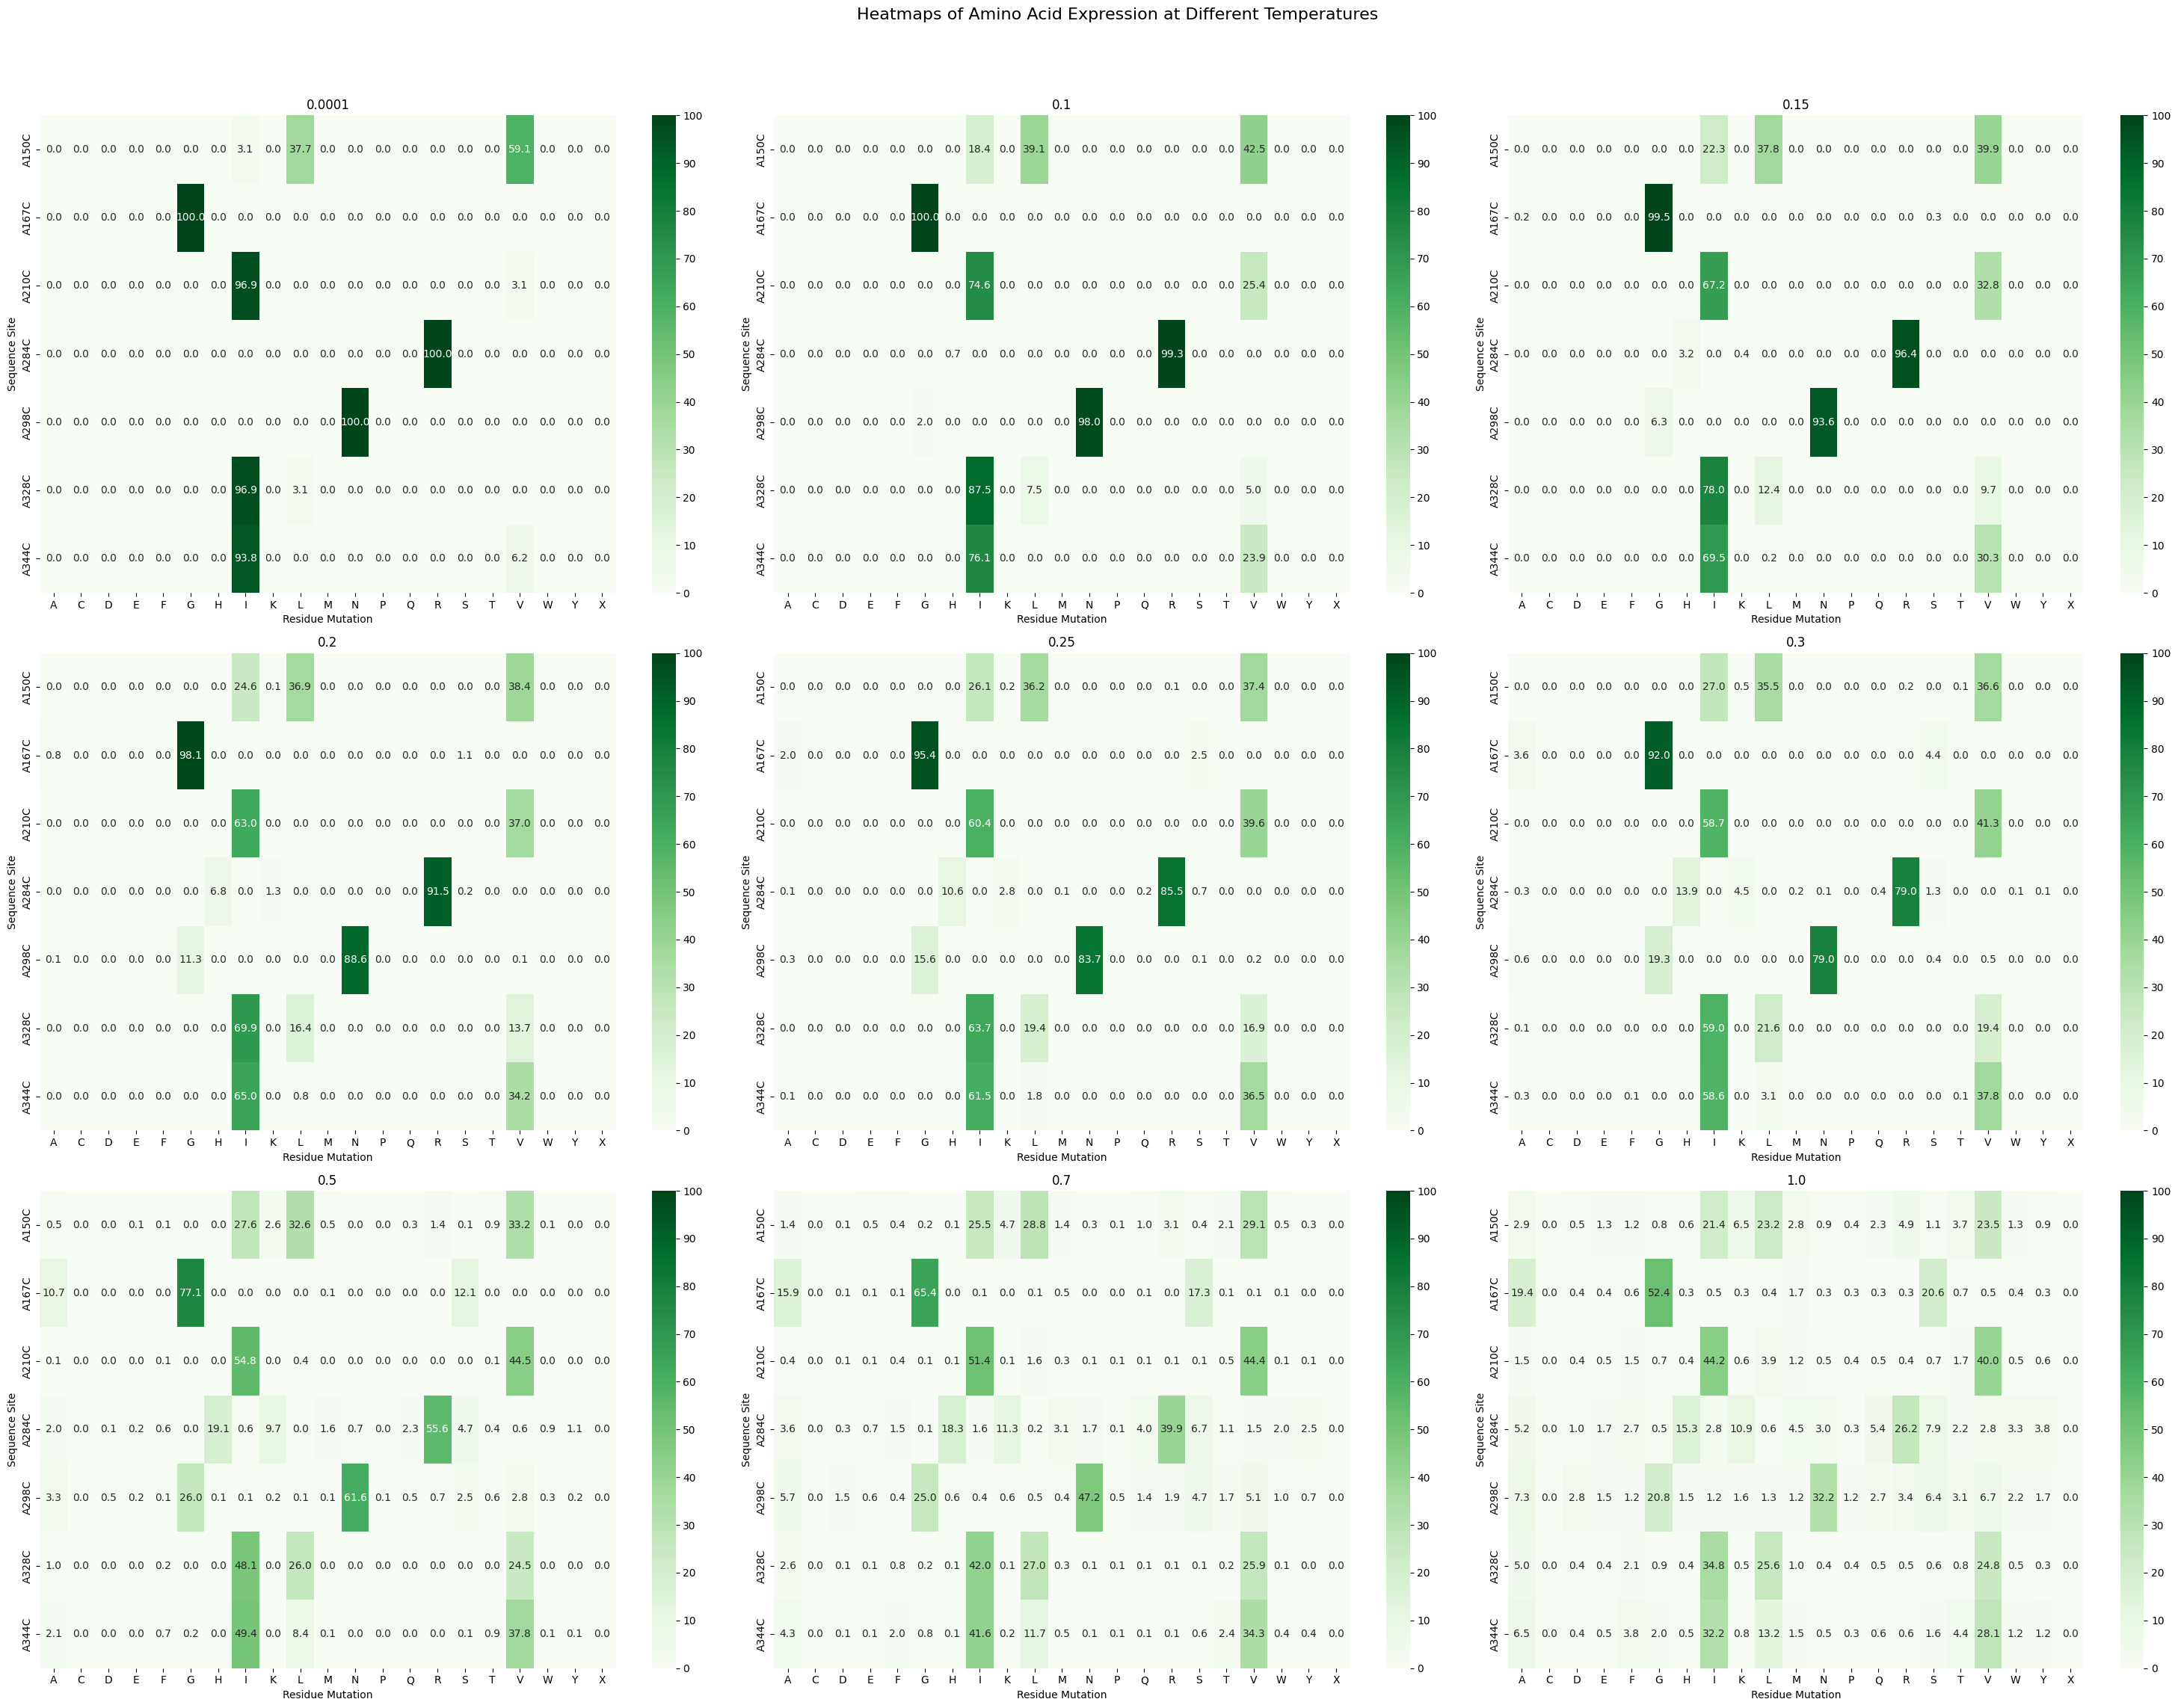

In [ ]:


def create_combined_heatmap(excel_file):
    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)
        num_sheets = len(all_sheets)

        # Determine the number of rows and columns for the subplot grid
        ncols = 3 # Number of columns in the grid
        nrows = (num_sheets + ncols - 1) // ncols # Calculate the number of rows needed

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*10, nrows*8))  # Adjust figure size as needed
        fig.suptitle("Heatmaps of Amino Acid Expression at Different Temperatures", fontsize=16) # Overall title

        sheet_index = 0
        for sheet_name, df in all_sheets.items():
            row_index = sheet_index // ncols
            col_index = sheet_index % ncols
            ax = axes[row_index, col_index] if num_sheets > 1 else axes # Handle single sheet case

            df = df.set_index(df.columns[0])
            df = df.apply(pd.to_numeric, errors='coerce').fillna(df.mean())

            vmin = 0
            vmax = 100
            heatmap = sns.heatmap(df, annot=True, cmap="Greens", fmt=".1f", vmin=vmin, vmax=vmax, ax=ax)

            ax.set_title(sheet_name)
            ax.set_xlabel("Residue Mutation")
            ax.set_ylabel("Sequence Site")

            cbar = heatmap.collections[0].colorbar
            cbar.set_ticks(np.arange(vmin, vmax + 1, 10))

            sheet_index += 1

        # Hide any unused subplots (if num_sheets is not a multiple of ncols)
        for i in range(sheet_index, nrows * ncols):
            row_index = i // ncols
            col_index = i % ncols
            if num_sheets > 1:
                axes[row_index, col_index].set_axis_off()
            else:
                axes.set_axis_off()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping with suptitle
        plt.savefig("combined_heatmap.png")
        plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")



file_path = '/content/MPNN_Temperature Data_mG6PC1.xlsx'  # Replace with your actual file path
create_combined_heatmap(file_path)

In [ ]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

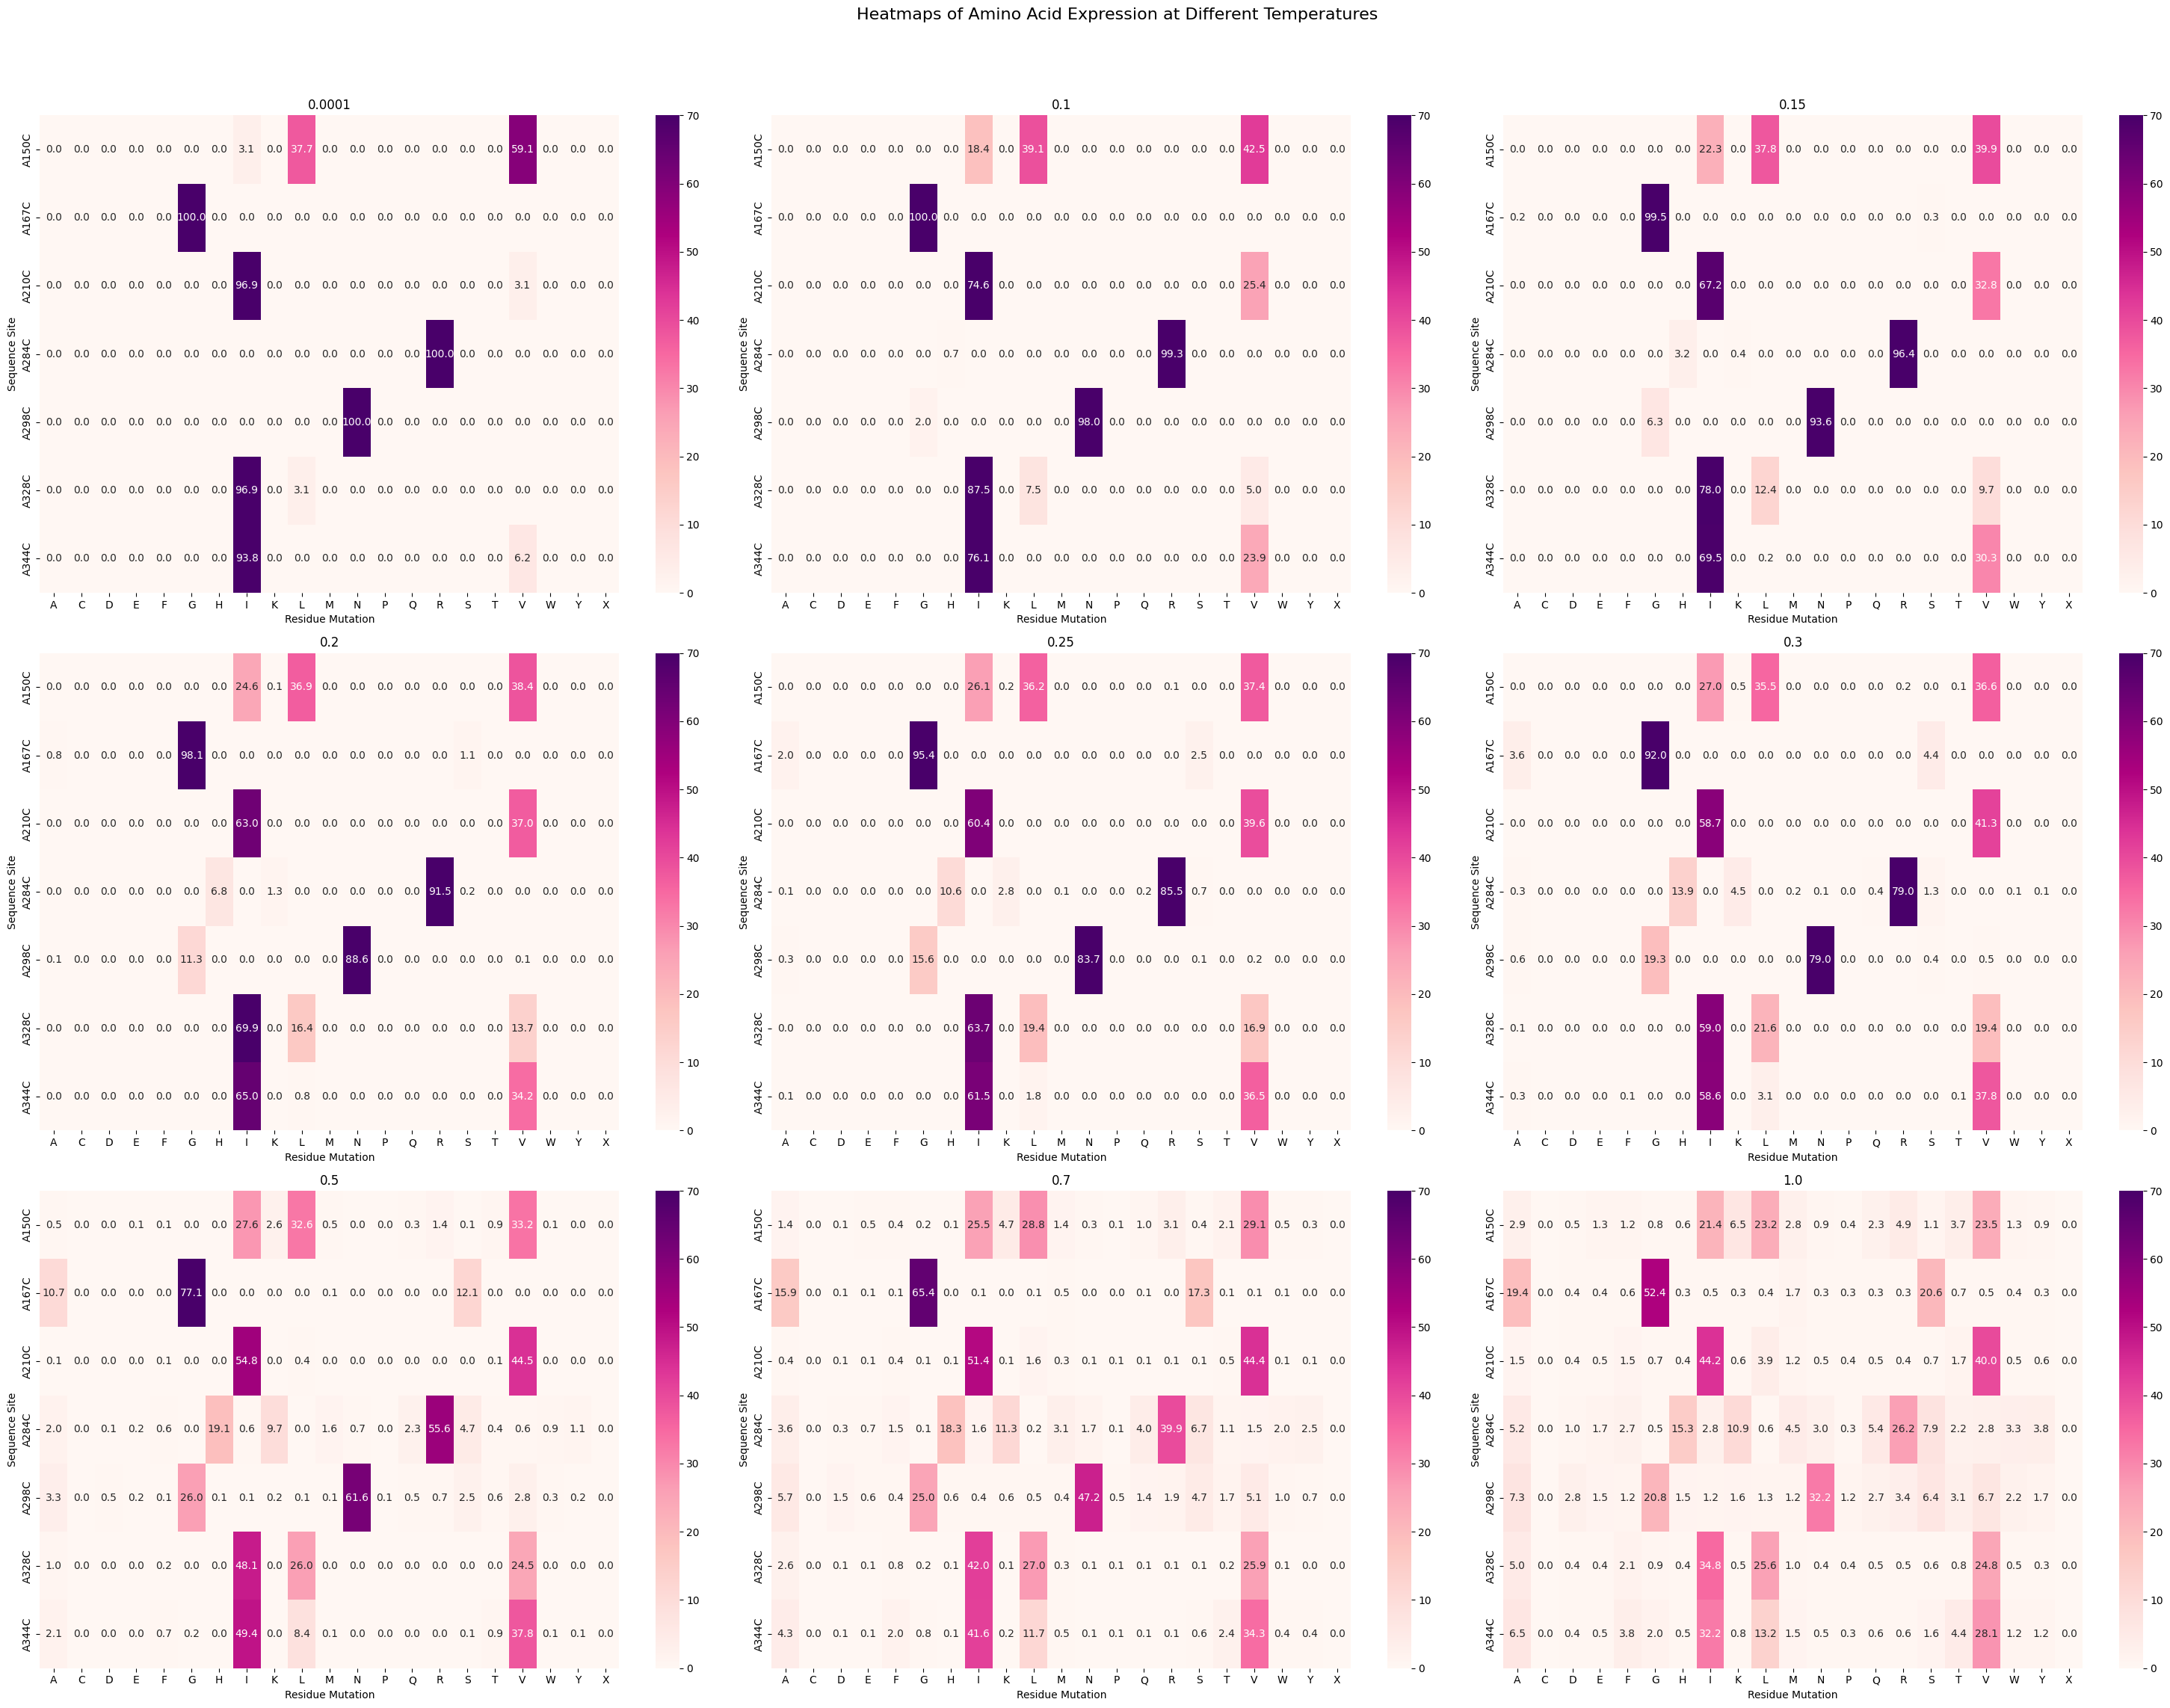

In [ ]:


def create_combined_heatmap(excel_file, filter_percentage=None):
    """
    Creates a combined heatmap from an Excel file with multiple sheets,
    optionally filtering data based on a percentage range.

    Args:
        excel_file (str): Path to the Excel file.
        filter_percentage (tuple, optional): A tuple representing the lower and upper
                                            percentage bounds for filtering (e.g., (0, 0.1) for 0-10%).
                                            Defaults to None, meaning no filtering.
    """
    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)
        num_sheets = len(all_sheets)

        ncols = 3
        nrows = (num_sheets + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 10, nrows * 8))
        fig.suptitle("Heatmaps of Amino Acid Expression at Different Temperatures", fontsize=16)

        sheet_index = 0
        for sheet_name, df in all_sheets.items():
            row_index = sheet_index // ncols
            col_index = sheet_index % ncols
            ax = axes[row_index, col_index] if num_sheets > 1 else axes

            df = df.set_index(df.columns[0])
            df = df.apply(pd.to_numeric, errors='coerce').fillna(df.mean())

            if filter_percentage:
                lower_bound = filter_percentage[0] * 100  # Convert percentage to actual value
                upper_bound = filter_percentage[1] * 100
                df = df[(df >= lower_bound) & (df <= upper_bound)] #Filter Dataframe

                # Handle the case where the filtering might result in an empty DataFrame
                if df.empty:
                    print(f"Warning: Sheet '{sheet_name}' is empty after filtering. Skipping.")
                    sheet_index += 1
                    continue  # Skip to the next sheet.

            vmin = 0
            vmax = 70
            heatmap = sns.heatmap(df, annot=True, cmap="RdPu", fmt=".1f", vmin=vmin, vmax=vmax, ax=ax)

            ax.set_title(sheet_name)
            ax.set_xlabel("Residue Mutation")
            ax.set_ylabel("Sequence Site")

            cbar = heatmap.collections[0].colorbar
            cbar.set_ticks(np.arange(vmin, vmax + 1, 10))

            sheet_index += 1

        for i in range(sheet_index, nrows * ncols):
            row_index = i // ncols
            col_index = i % ncols
            if num_sheets > 1:
                axes[row_index, col_index].set_axis_off()
            else:
                axes.set_axis_off()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig("combined_heatmap.png")
        plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

sns.color_palette("Paired")
# Example usage:
excel_file_path = '/content/MPNN_Temperature Data_mG6PC1.xlsx'  # Replace with your file path

# To filter between 0% and 10%:
create_combined_heatmap(excel_file_path, filter_percentage=(0, 1.0))

# To filter between 20% and 50%:
#create_combined_heatmap(excel_file_path, filter_percentage=(0.2, 0.5))

# To create the heatmap without any filtering:
#create_combined_heatmap(excel_file_path)

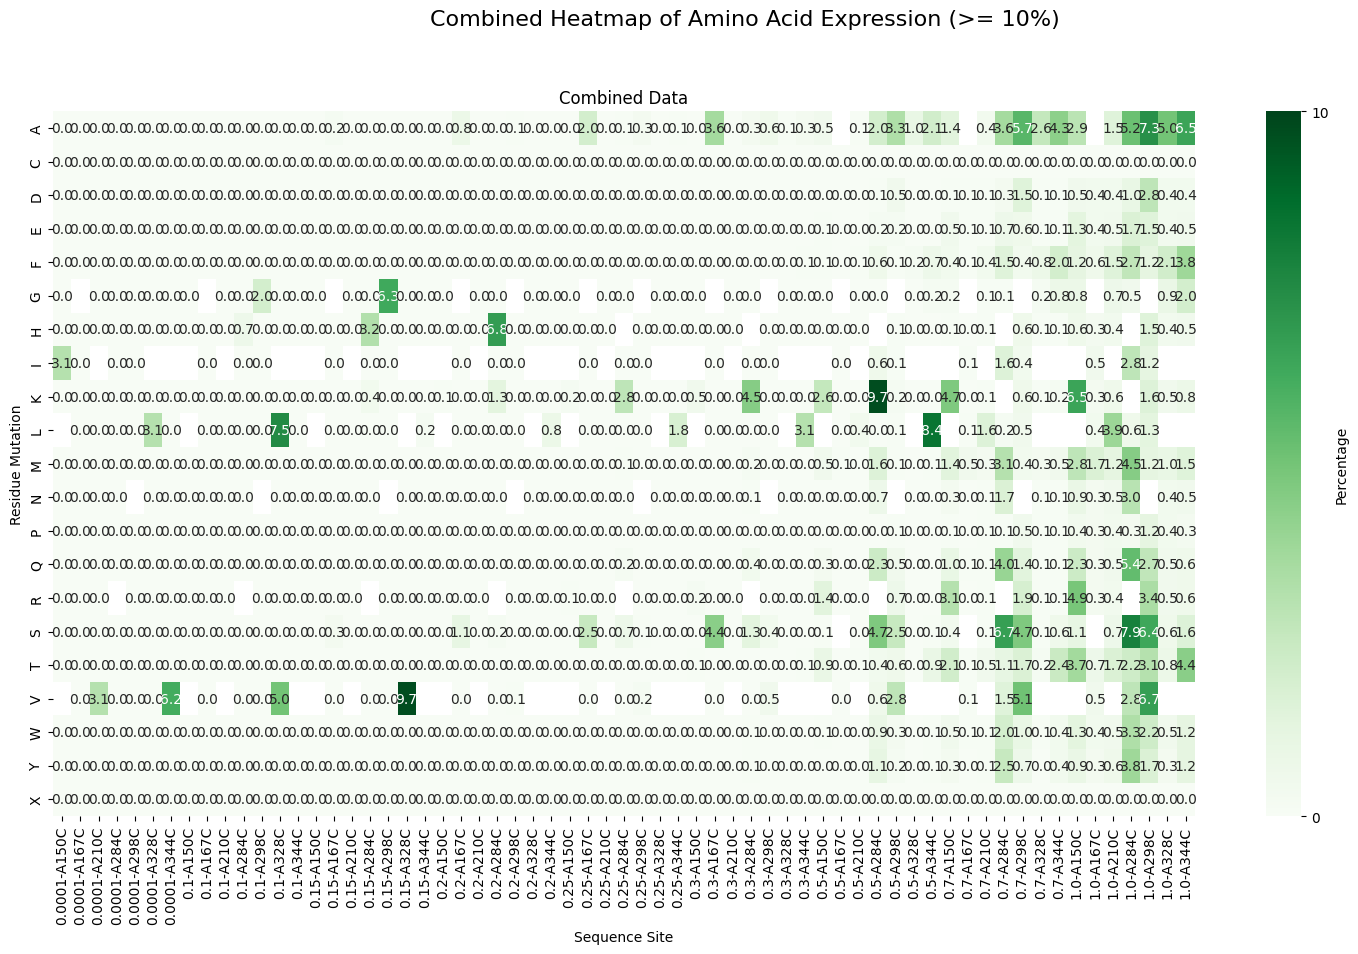

In [ ]:


def create_combined_heatmap(excel_file):
    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)

        dfs_to_combine = []

        for sheet_name, df in all_sheets.items():
            df = df.set_index(df.columns[0])
            df = df.apply(pd.to_numeric, errors='coerce').fillna(df.mean())
            df_filtered = df[df <= 10 ].dropna(how='all')
            dfs_to_combine.append(df_filtered)

        combined_df = pd.concat(dfs_to_combine, keys=all_sheets.keys())

        # Transpose the combined DataFrame to plot rows as columns
        combined_df = combined_df.groupby(level=[0,1]).mean().T  # Group by sheet and sequence site, then transpose

        fig, ax = plt.subplots(figsize=(15, 10))
        fig.suptitle("Combined Heatmap of Amino Acid Expression (>= 10%)", fontsize=16)

        vmin = 0
        vmax = 10
        heatmap = sns.heatmap(combined_df, annot=True, cmap="Greens", fmt=".1f", vmin=vmin, vmax=vmax, ax=ax, cbar_kws={'label': 'Percentage'})

        ax.set_title("Combined Data")
        ax.set_xlabel("Sequence Site")  # X-axis now shows sequence sites
        ax.set_ylabel("Residue Mutation") # Y-axis now shows mutations

        cbar = heatmap.collections[0].colorbar
        cbar.set_ticks(np.arange(vmin, vmax + 1, 10))

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig("combined_heatmap.png")
        plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

file_path = '/content/MPNN_Temperature Data_mG6PC1.xlsx'
create_combined_heatmap(file_path)

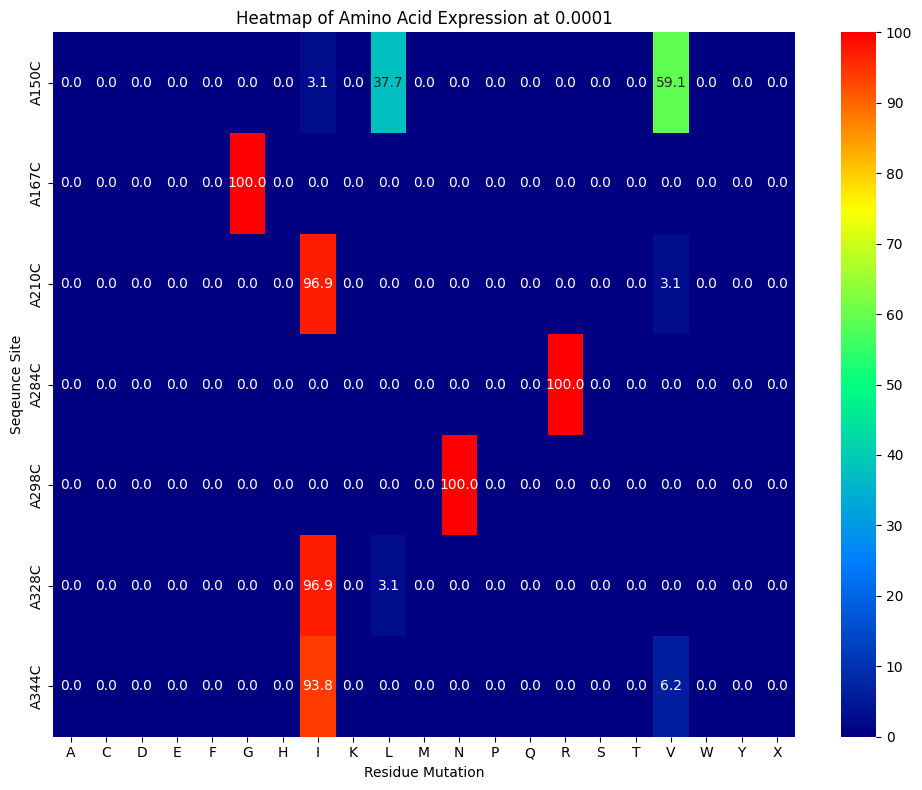

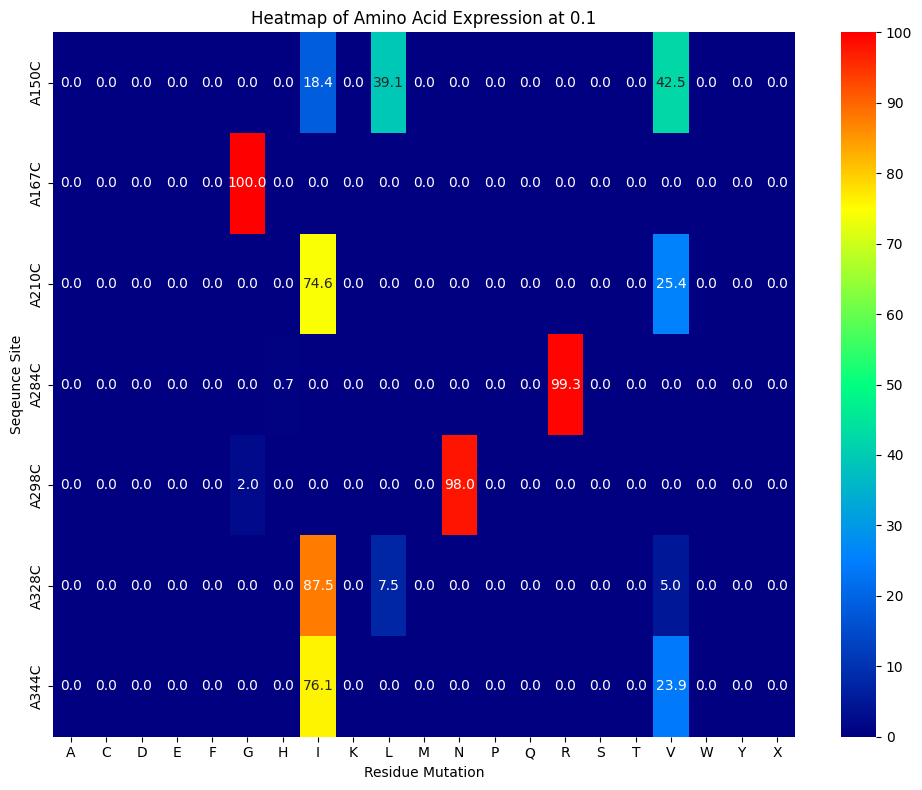

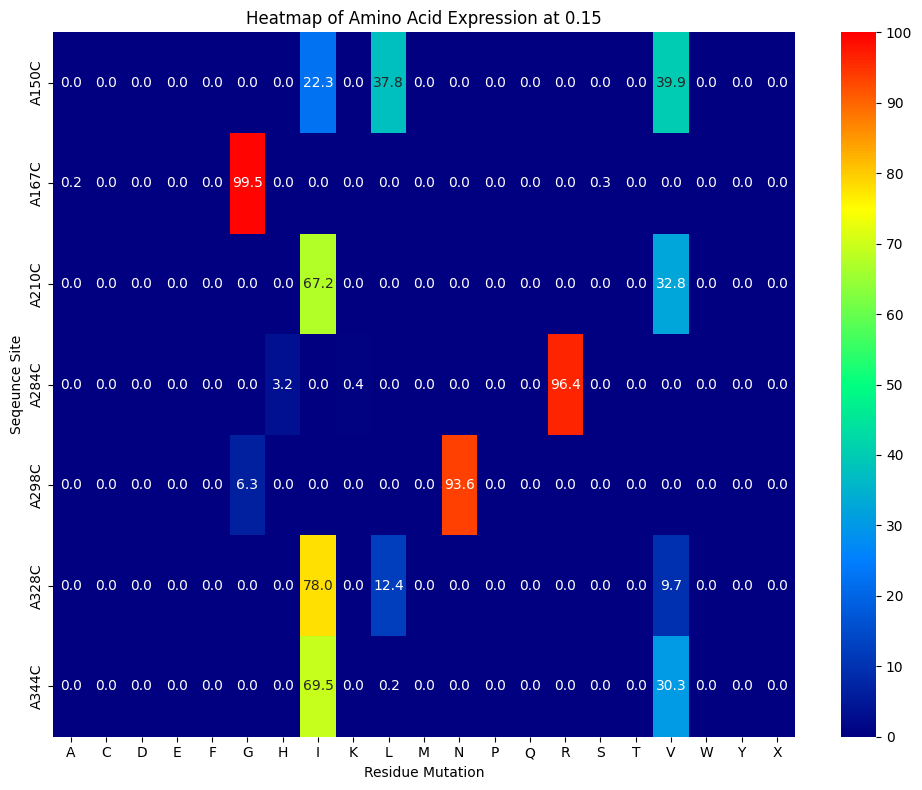

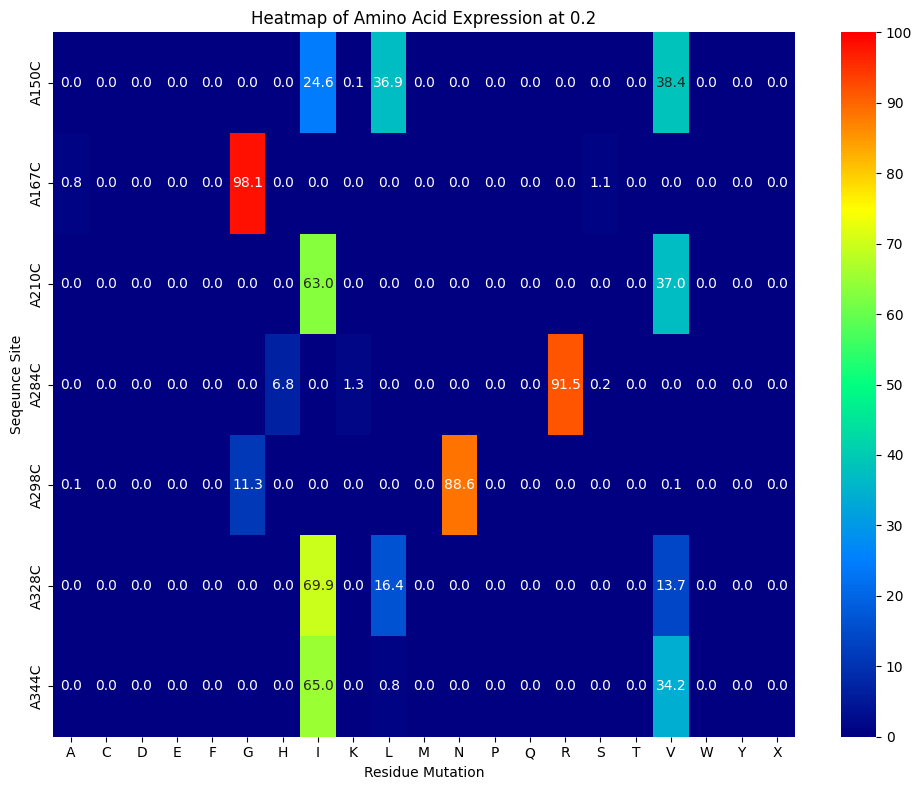

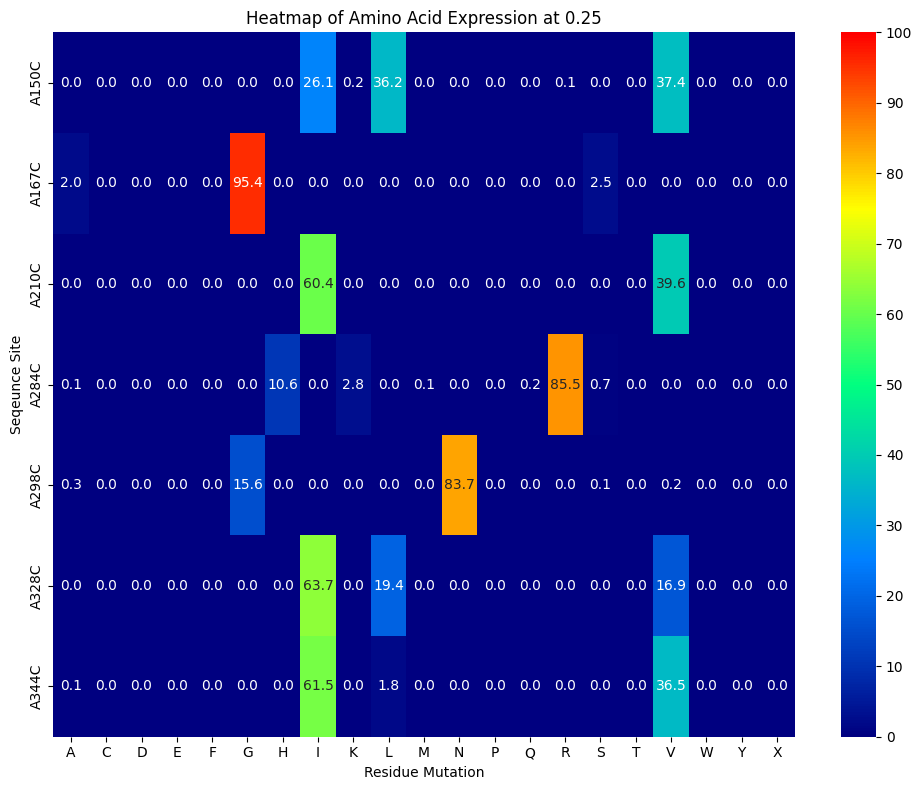

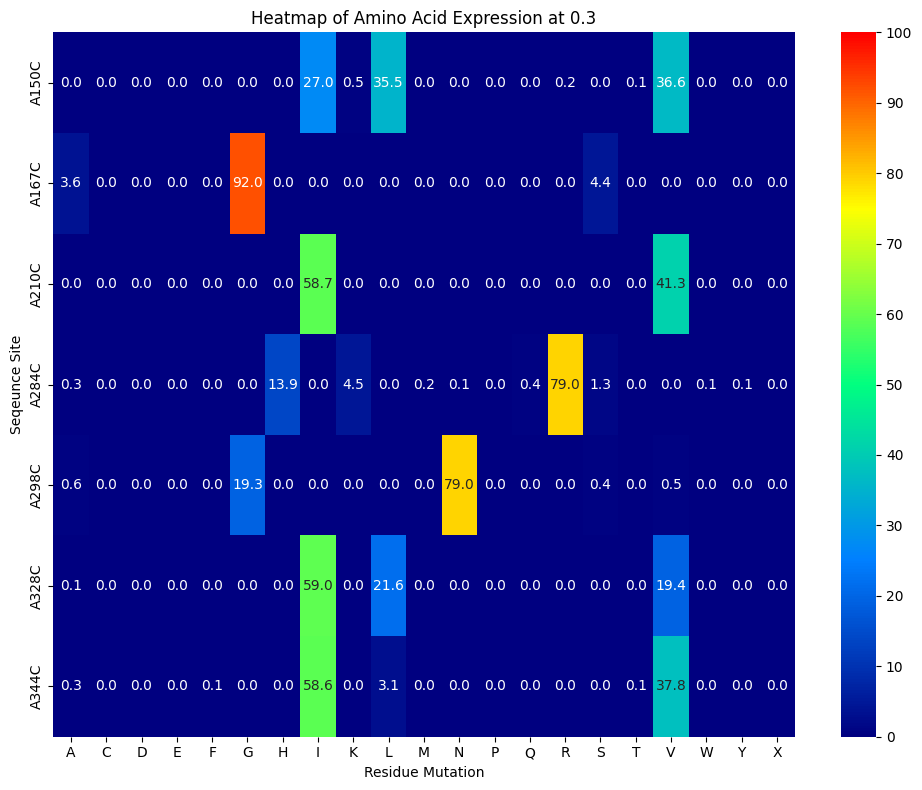

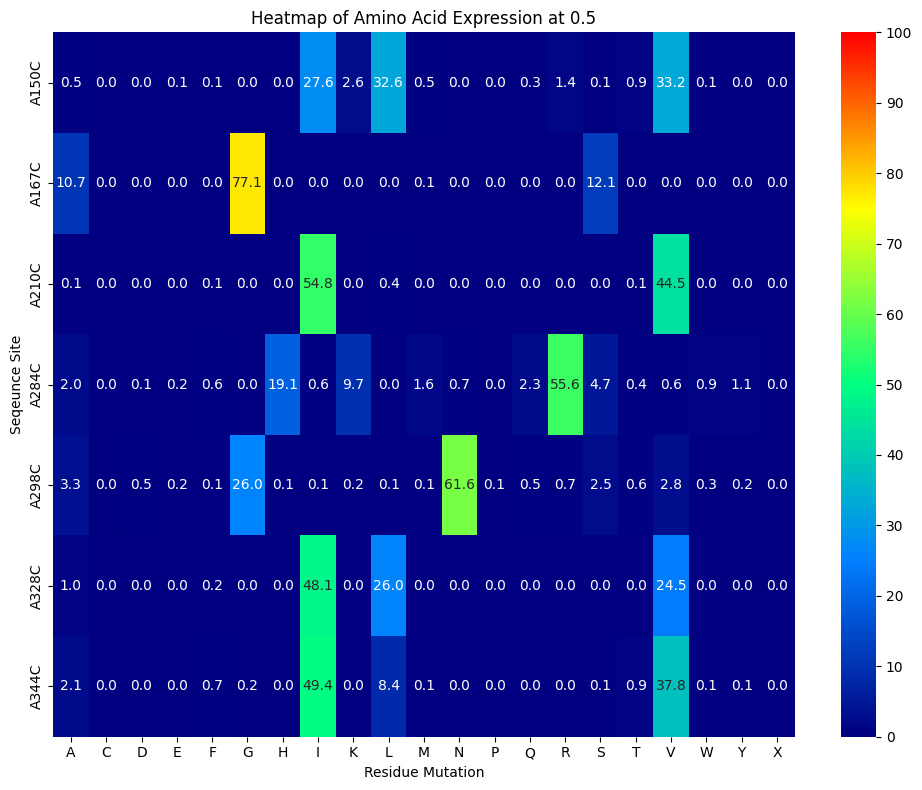

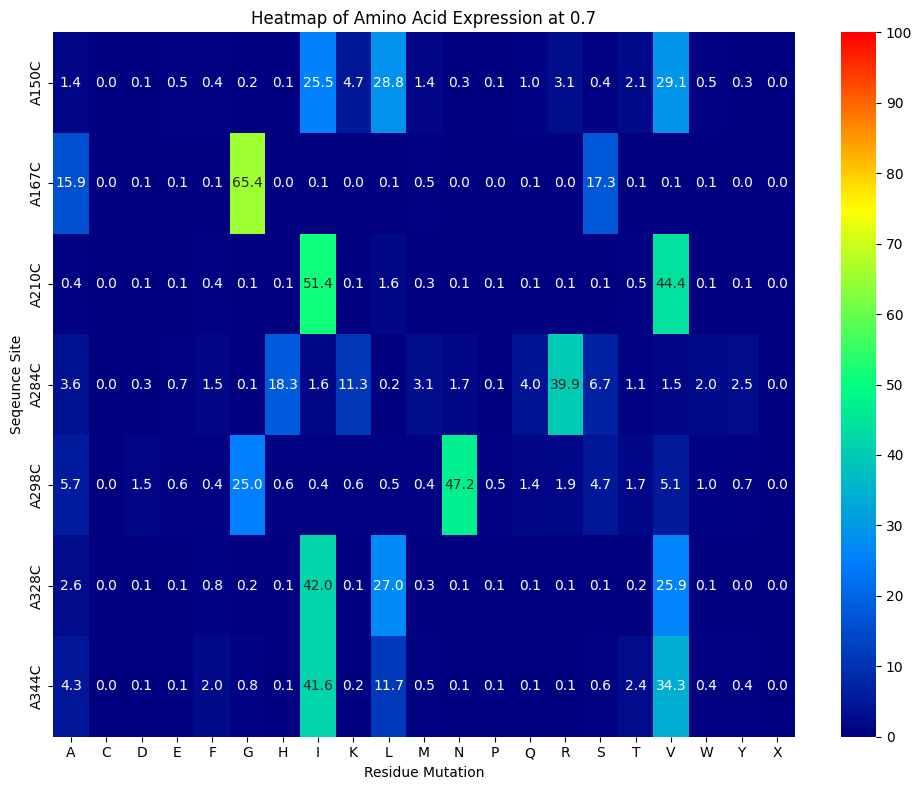

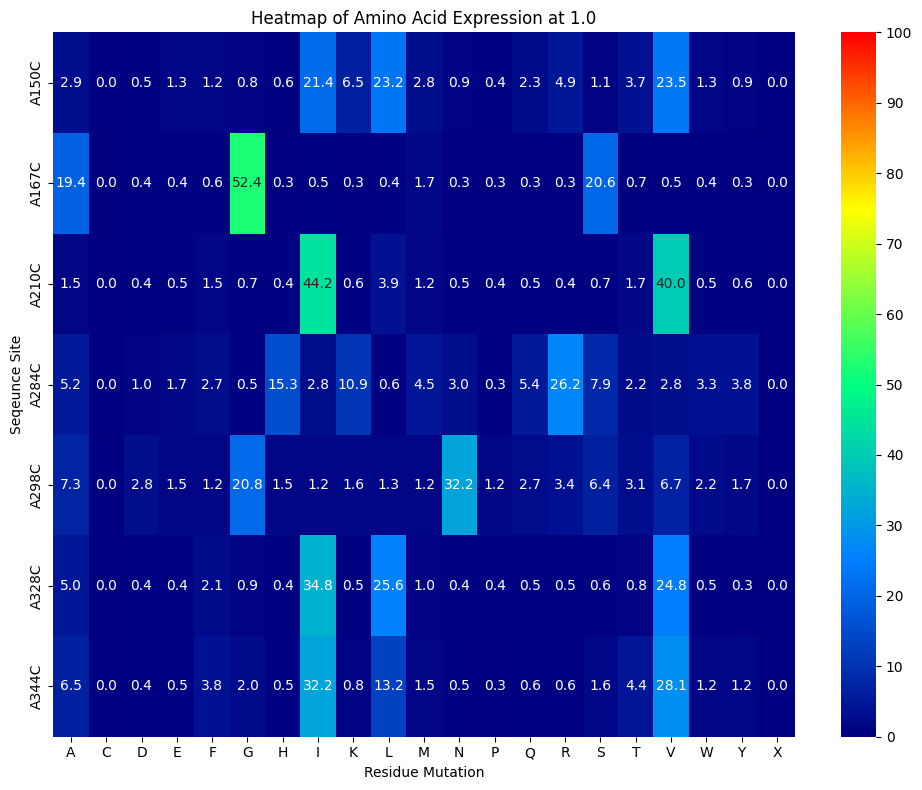

In [ ]:

from matplotlib.colors import LinearSegmentedColormap

def create_heatmaps_from_excel(excel_file):
    """
    Generates heatmaps from an Excel file with custom diverging color scales.

    Args:
        excel_file (str): Path to the Excel file.
    """

    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)

        for sheet_name, df in all_sheets.items():
            df = df.set_index(df.columns[0])

            try:
                df = df.apply(pd.to_numeric, errors='coerce')
            except Exception as e:
                print(f"Error converting data to numeric in sheet '{sheet_name}': {e}")
                continue

            df = df.fillna(df.mean())

            vmin = 0
            vmax = 100

            plt.figure(figsize=(10, 8))

            # Create custom diverging colormaps
            colors_0_25 = [(0.0, 0.0, 0.5), (0.0, 0.5, 1.0)]  # Dark blue to light blue
            cmap_0_25 = LinearSegmentedColormap.from_list("cmap_0_25", colors_0_25)

            colors_25_50 = [(0.0, 0.5, 1.0), (0.0, 1.0, 0.5)]  # Light blue to light green
            cmap_25_50 = LinearSegmentedColormap.from_list("cmap_25_50", colors_25_50)

            colors_50_75 = [(0.0, 1.0, 0.5), (1.0, 1.0, 0.0)]  # Light green to yellow
            cmap_50_75 = LinearSegmentedColormap.from_list("cmap_50_75", colors_50_75)

            colors_75_100 = [(1.0, 1.0, 0.0), (1.0, 0.0, 0.0)]  # Yellow to red
            cmap_75_100 = LinearSegmentedColormap.from_list("cmap_75_100", colors_75_100)


            # Combine the colormaps
            combined_cmap = LinearSegmentedColormap.from_list("combined_cmap", colors_0_25 + colors_25_50[1:] + colors_50_75[1:] + colors_75_100[1:])


            heatmap = sns.heatmap(df, annot=True, cmap=combined_cmap, fmt=".1f", vmin=vmin, vmax=vmax)

            plt.title(f"Heatmap of Amino Acid Expression at {sheet_name}")
            plt.xlabel("Residue Mutation")
            plt.ylabel("Seqeunce Site")
            plt.tight_layout()

            cbar = heatmap.collections[0].colorbar
            cbar.set_ticks(np.arange(vmin, vmax + 1, 10))

            plt.savefig(f"MPNNTempheatmap_{sheet_name}.png")
            plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")


excel_file = '/content/MPNN_Temperature Data_mG6PC1.xlsx'  # Replace with your Excel file path
create_heatmaps_from_excel(excel_file)

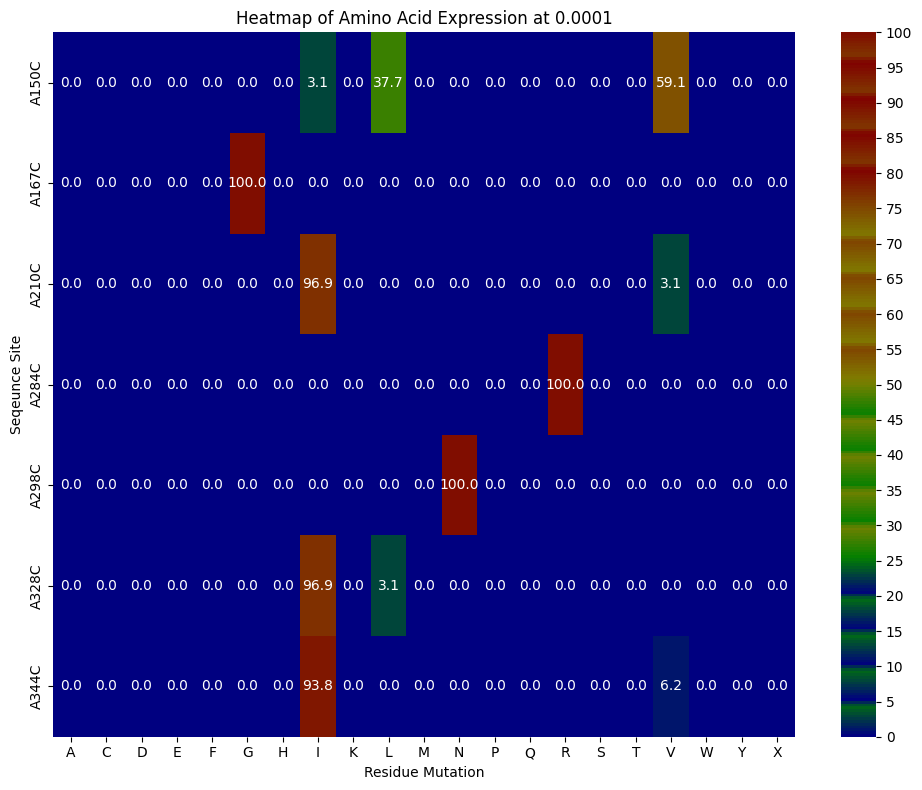

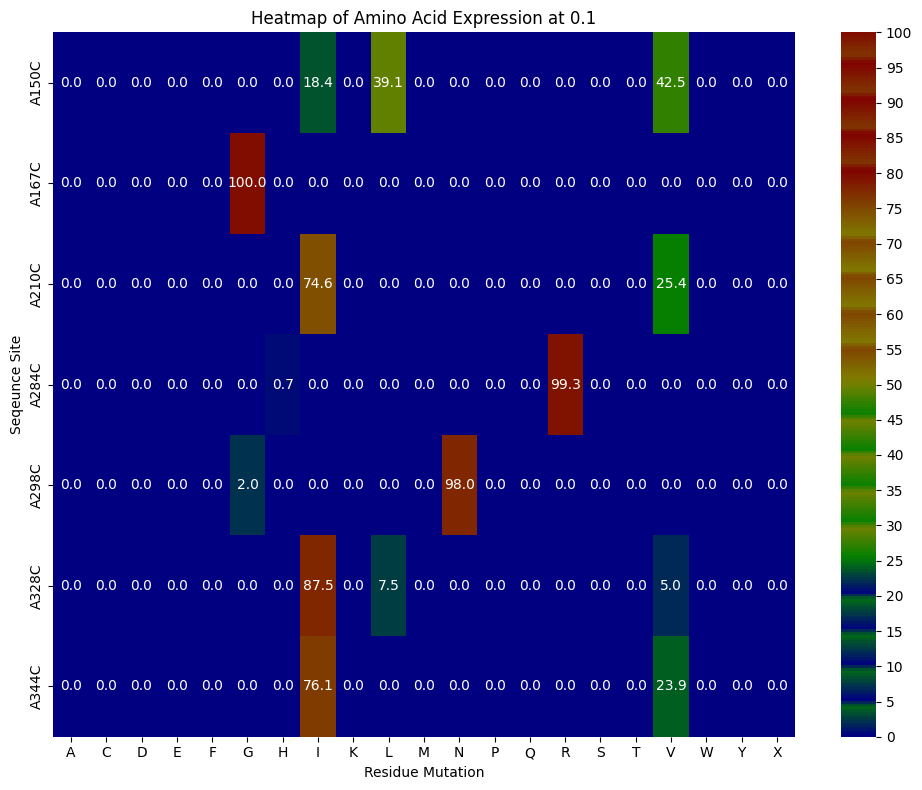

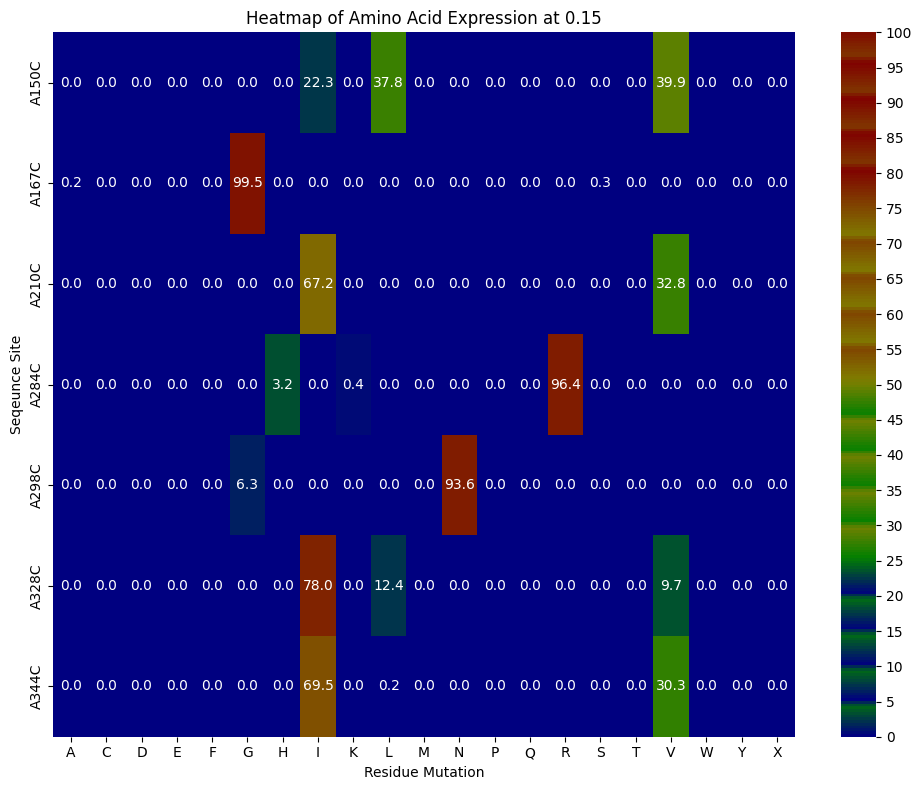

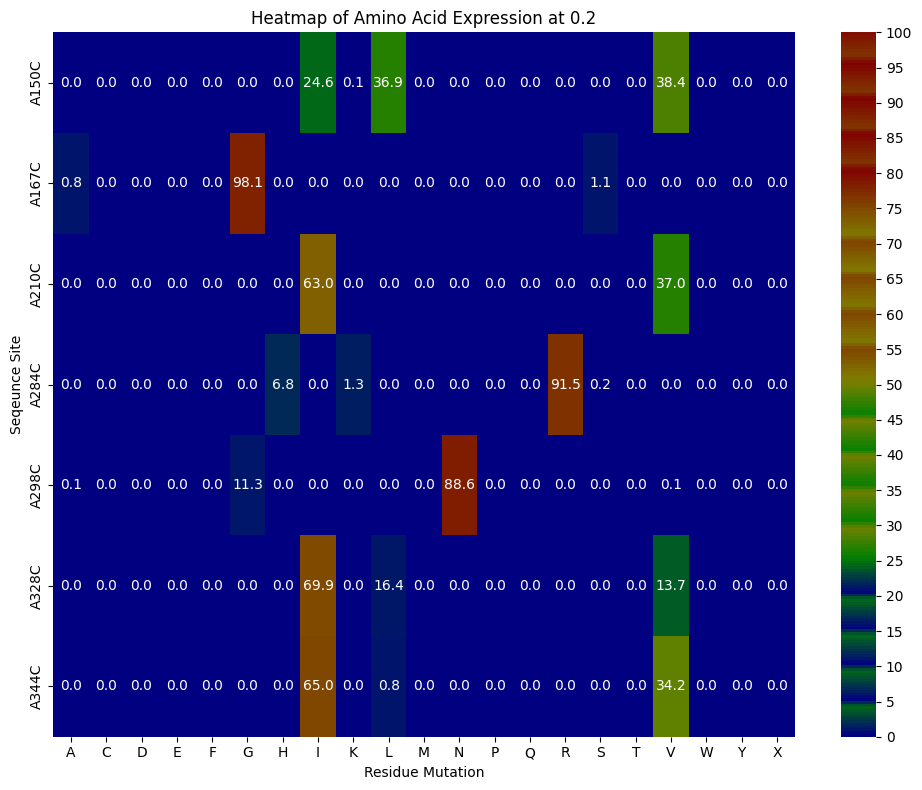

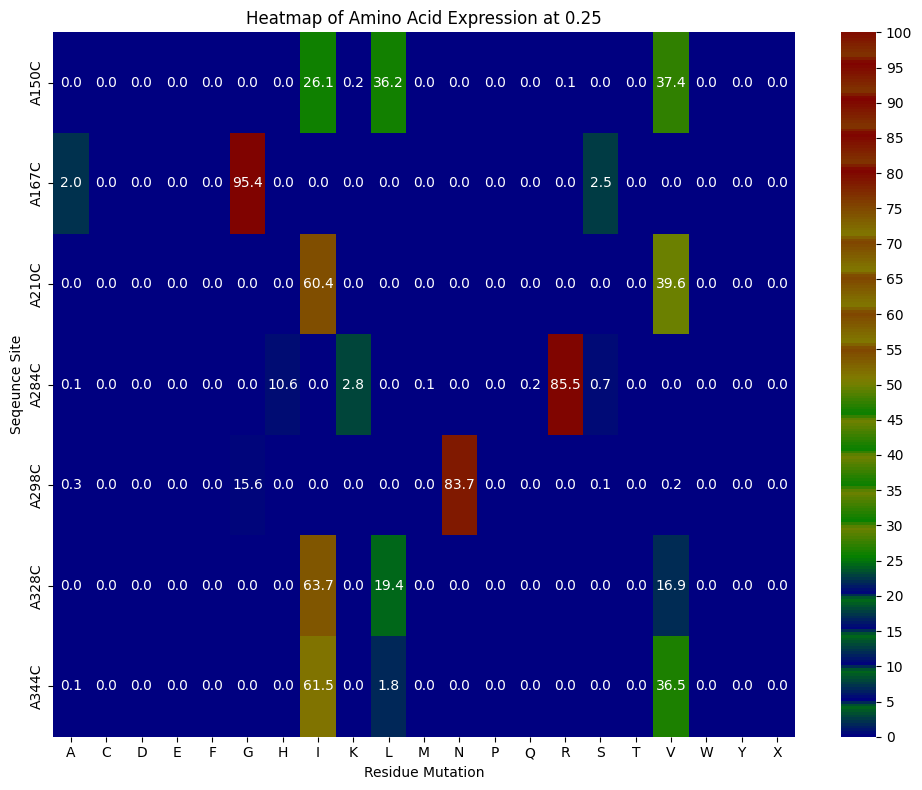

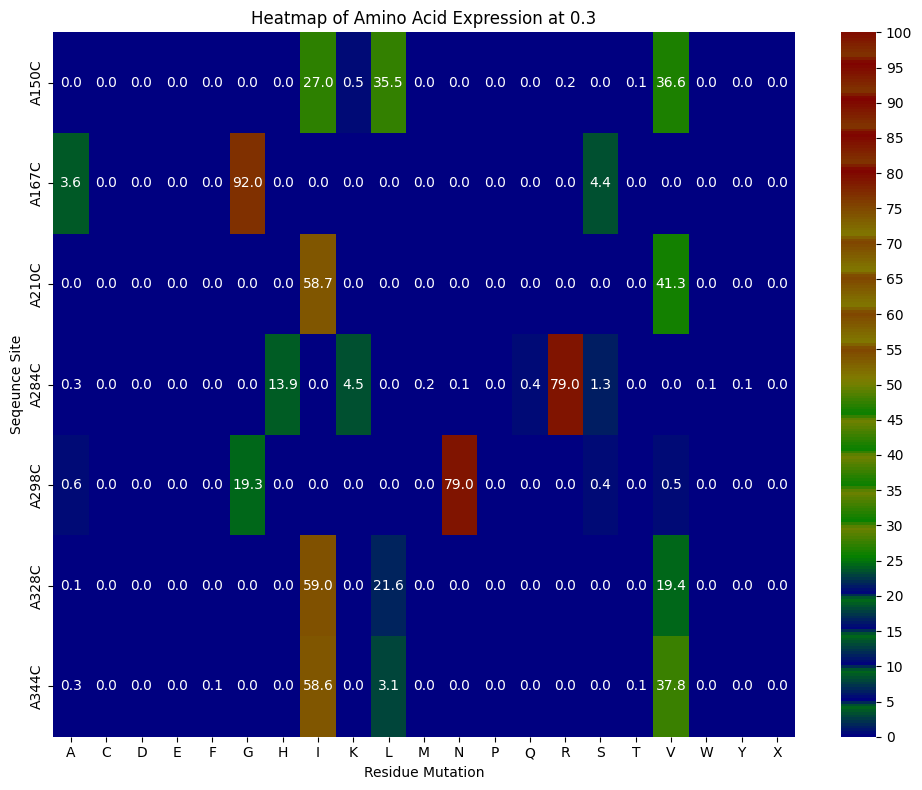

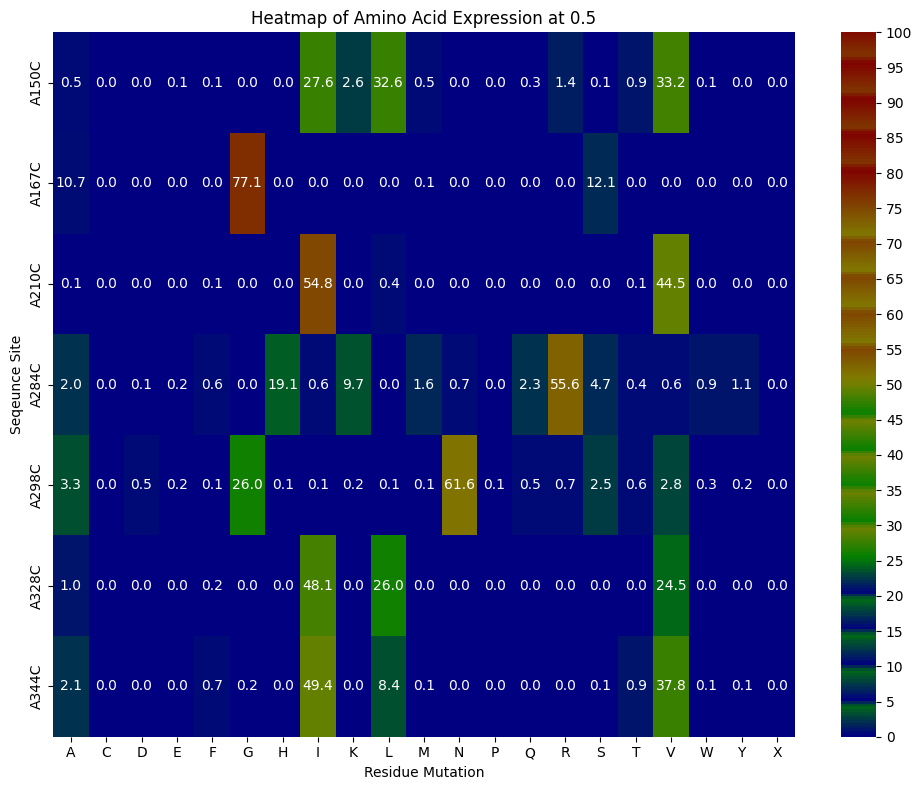

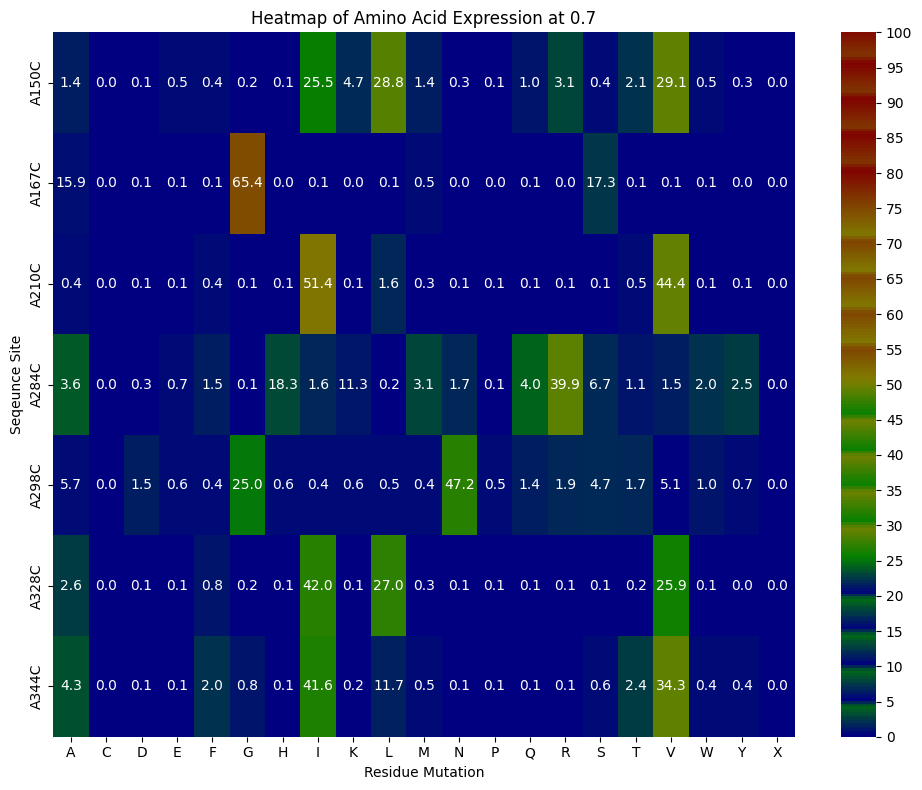

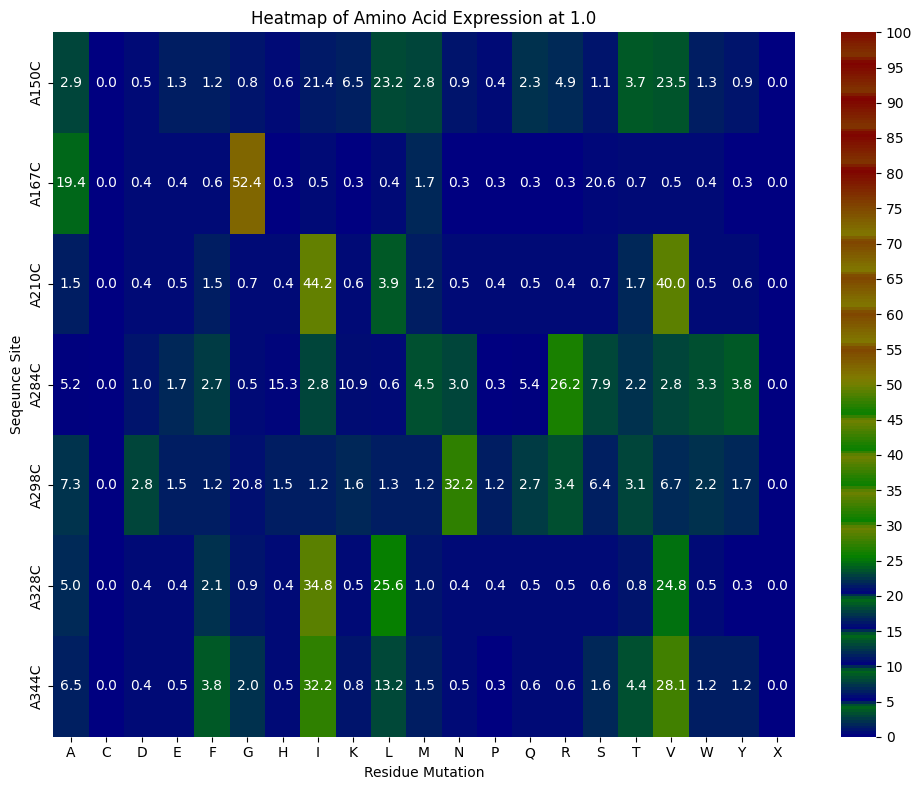

In [ ]:


def create_heatmaps_from_excel(excel_file):
    """
    Generates heatmaps from an Excel file with custom diverging color scales every 5 units.

    Args:
        excel_file (str): Path to the Excel file.
    """

    try:
        all_sheets = pd.read_excel(excel_file, sheet_name=None)

        for sheet_name, df in all_sheets.items():
            df = df.set_index(df.columns[0])

            try:
                df = df.apply(pd.to_numeric, errors='coerce')
            except Exception as e:
                print(f"Error converting data to numeric in sheet '{sheet_name}': {e}")
                continue

            df = df.fillna(df.mean())

            vmin = 0
            vmax = 100

            plt.figure(figsize=(10, 8))

            # Create custom diverging colormaps every 5 units
            cmaps = []
            for i in range(0, 100, 5):
                # Define distinct color ranges.  Experiment with these!
                if i < 25:  # Example: Blues to Greens
                  colors = [(0.0, 0.0, 0.5), (0.0, 0.5, 0.0)]
                elif i < 50: # Example: Greens to Yellows
                  colors = [(0.0, 0.5, 0.0), (0.5, 0.5, 0.0)]
                elif i < 75: # Example: Yellows to Oranges
                  colors = [(0.5, 0.5, 0.0), (0.5, 0.25, 0.0)]
                else: # Example: Oranges to Reds
                  colors = [(0.5, 0.25, 0.0), (0.5, 0.0, 0.0)]

                cmap = LinearSegmentedColormap.from_list(f"cmap_{i}", colors)
                cmaps.append(cmap)

            # Combine the colormaps.  This is a bit more complex now.
            combined_colors = []
            for i in range(0, 100, 5):
                start = i / 100
                end = (i + 5) / 100
                for j in range(0, 100): # Refine color transitions
                  val = j / 99 # 0 to 1
                  if start <= val < end:
                    color_index = int(i / 5)
                    color_val = (val - start) / (end - start)
                    combined_colors.append(cmaps[color_index](color_val))


            combined_cmap = LinearSegmentedColormap.from_list("combined_cmap", combined_colors)

            heatmap = sns.heatmap(df, annot=True, cmap=combined_cmap, fmt=".1f", vmin=vmin, vmax=vmax)

            plt.title(f"Heatmap of Amino Acid Expression at {sheet_name}")
            plt.xlabel("Residue Mutation")
            plt.ylabel("Seqeunce Site")
            plt.tight_layout()

            cbar = heatmap.collections[0].colorbar
            cbar.set_ticks(np.arange(vmin, vmax + 1, 5))  # Ticks every 5

            plt.savefig(f"MPNNTempheatmap_{sheet_name}.png")
            plt.show()

    except FileNotFoundError:
        print(f"Error: Excel file '{excel_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")


excel_file = '/content/MPNN_Temperature Data_mG6PC1.xlsx'  # Replace with your Excel file path
create_heatmaps_from_excel(excel_file)